# Outline
- Use Multivariate and Univariate Techniques to identify Outliers.

- Apply Multivariate Techniques on Area,Bath(s),Bedroom(s),Kitchens, etc

In [7]:
import numpy as np
import pandas as pd

import seaborn as sns

In [8]:
flats = pd.read_csv('../2. EDA/flats.csv',index_col=0)

In [9]:
flats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743 entries, 7 to 6481
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Building                            1743 non-null   object 
 1   Main Location                       1743 non-null   object 
 2   Type                                1743 non-null   object 
 3   Price(Cr)                           1743 non-null   float64
 4   Bath(s)                             1722 non-null   float64
 5   Area(Marla)                         1743 non-null   float64
 6   Bedroom(s)                          1703 non-null   float64
 7   Description                         1743 non-null   object 
 8   Amenities: Main Features            1613 non-null   object 
 9   Amenities: Rooms                    1545 non-null   object 
 10  Amenities: Healthcare Recreational  1268 non-null   object 
 11  Amenities: Other Facilities         1516 non-nul

In [10]:
flats.isnull().sum()

Building                                 0
Main Location                            0
Type                                     0
Price(Cr)                                0
Bath(s)                                 21
Area(Marla)                              0
Bedroom(s)                              40
Description                              0
Amenities: Main Features               130
Amenities: Rooms                       198
Amenities: Healthcare Recreational     475
Amenities: Other Facilities            227
IsPrimeLoc                               0
SolarInstalled                           0
WaterBore                                0
CornerHouse                              0
luxury_type                              0
Built in year                          327
Parking Spaces                         236
Floor                                  604
Lobby in Building                      498
Elevators                              598
Service Elevators in Building          650
Floor in Bu

In [11]:
flats.describe()

,Price(Cr),Bath(s),Area(Marla),Bedroom(s),luxury_type,Built in year,Parking Spaces,Floor,Lobby in Building,Elevators,...,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
count,1743.000000,1722.000000,1743.000000,1703.000000,1743.000000,1416.000000,1507.000000,1139.000000,1245.0,1145.000000,...,1126.000000,0.0,1095.0,1087.0,1512.0,1296.0,1122.0,726.0,539.0,229.000000
mean,2.709687,2.209640,5.993287,2.120376,0.196787,1832.294492,7.183809,3.761194,1.0,2.523144,...,0.927176,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.026201
std,3.640221,1.076213,6.330634,0.952553,0.397684,589.361141,117.028725,5.294744,0.0,2.630449,...,0.632476,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.821431
min,0.220000,1.000000,0.700000,1.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,...,-1.000000,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
25%,0.800000,1.000000,3.300000,1.000000,0.000000,2018.000000,1.000000,1.000000,1.0,1.000000,...,1.000000,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000
50%,1.450000,2.000000,4.900000,2.000000,0.000000,2023.000000,1.000000,2.000000,1.0,2.000000,...,1.000000,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.000000
75%,3.300000,3.000000,7.500000,3.000000,0.000000,2025.000000,2.000000,5.000000,1.0,3.000000,...,1.000000,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.000000
max,60.000000,9.000000,222.000000,11.000000,1.000000,2054.000000,4000.000000,123.000000,1.0,20.000000,...,11.000000,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.000000


## Univariate Approach
- Z Score --> Normal Distributions
- IQR --> Non Normal Distributions

In [12]:
# Price

<Axes: ylabel='Price(Cr)'>

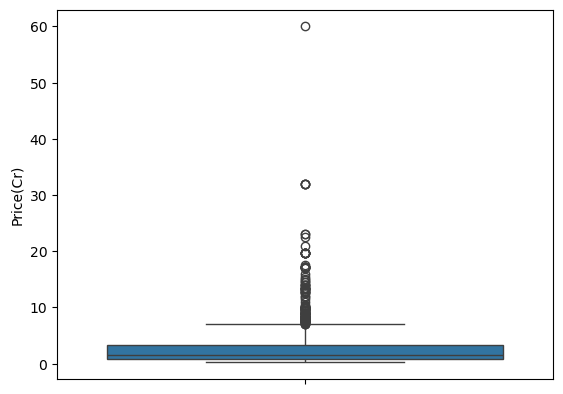

In [13]:
sns.boxplot(flats['Price(Cr)'])

In [14]:
# Investigating flats above the price of 10
flats[flats['Price(Cr)']>10]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
8,Karakoram Diplomatic Enclave,Karakoram Diplomatic Enclave,Flat,13.25,4.0,11.8,3.0,Luxurious 3-Bedroom Fully Furnished Corner Apa...,"Lobby in Building, Central Air Conditioning, C...",NaN,...,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN
32,The Centaurus,F-8,Flat,19.64,4.0,13.4,2.0,Ultra Luxury 2 Bedroom Duplex Apartment with M...,"Built in year: 2022, Parking Spaces: 1, Lobby ...","Bedrooms: 2, Bathrooms: 4, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
191,Sukh Chayn Residence,F-10,Flat,12.00,4.0,12.4,4.0,Best opportunity for investment. . . . Brand N...,"Built in year: 2025, Parking Spaces: 2, Lobby ...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
192,Sukh Chayn Residence,F-10,Flat,13.25,5.0,12.4,4.0,The Convenient And Stunning Neighbourhood Of S...,"Built in year: 2025, Parking Spaces: 2, Lobby ...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 2...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
199,Constitution Avenue,Constitution Avenue,Flat,23.00,6.0,19.3,4.0,4-Bedroom Apartment for Sale One Constitution ...,"Built in year: 2023, Parking Spaces: 3, Lobby ...","Bedrooms: 4, Bathrooms: 7, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
260,Diplomatic Enclave,Diplomatic Enclave,Flat,12.50,3.0,12.2,3.0,3 Bedroom Modern Apartment Furnished Margalla ...,"Parking Spaces: 4, Double Glazed Windows, Cent...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...",...,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
345,The Centaurus,F-8,Flat,17.17,5.0,11.7,3.0,*Purchase Directly from Centaurus Managment *T...,"Built in year: 2022, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
348,The Centaurus,F-8,Flat,17.17,5.0,11.7,3.0,Three Bedroom Apartment with Maid Room Demand:...,"Built in year: 2023, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
356,The Centaurus,F-8,Flat,17.17,5.0,11.7,3.0,Three Bedroom Apartment with Maid Room Demand:...,"Built in year: 2023, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
357,The Centaurus,F-8,Flat,19.64,4.0,13.4,2.0,Ultra Luxury 2 Bedroom Duplex Apartment With M...,"Built in year, Parking Spaces: 1, Lobby in Bui...","Bedrooms: 2, Bathrooms: 4, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN


In [15]:
flats['Description'].loc[5556]

"F-10 Sukh Chayn 4 Bedroom Penthouse With DD, Tv Lounge , Kitchen All Accessories More Detail Please Contact If you wish to purchase a fine piece of property in Islamabad, check this one. Considering buying property? Explore your options here with the best offers listed. Searching for 50000 Square Feet sized properties? You have come to the right place. Another piece of property just came up in F-10 Markaz. Take a chance and it may just be yours at a moments notice. Here's the Penthouse, we believe will be perfect for your needs. Investing at a price of PKR Rs. 600000000 to own property can be the best decision you'll ever take. To purchase your home at the best prices, drop us a line today."

In [16]:
flats['Description'].loc[4136]

'Luxury 5-Bed Flat For Sale in Sukh Chayn Residence, F-10 Islamabad Experience premium living in the heart of Islamabad with this spacious and elegantly designed 5-bedroom penthouse located in the prestigious Sukh Chayn Residence, F-10. Key Features: 5 Spacious Bedrooms with Attached Modern Bathrooms Stylish Drawing & Dining Area Fully Equipped Kitchen with Quality Fittings Panoramic Views of Islamabad from Wide Balconies & Terraces Elegant Flooring & High-End Interior Finishing Secure & Well-Maintained Building Building Amenities: 24/7 Security & CCTV Monitoring High-Speed Elevators Standby Power Backup Covered Car Parking Gym, Swimming Pool & Community Spaces Ideal Location with Easy Access to Schools, Markets & Main Roads Prime Location: Located in F-10 Markaz, one of Islamabads most sought-after areas, offering both luxury and convenience. Best Investment Opportunity A perfect choice for families seeking upscale living or investors looking for high rental value.'

*Removing rows where the Price(Cr) is greater than 30*

In [17]:
flats = flats[~(flats['Price(Cr)']>30)]

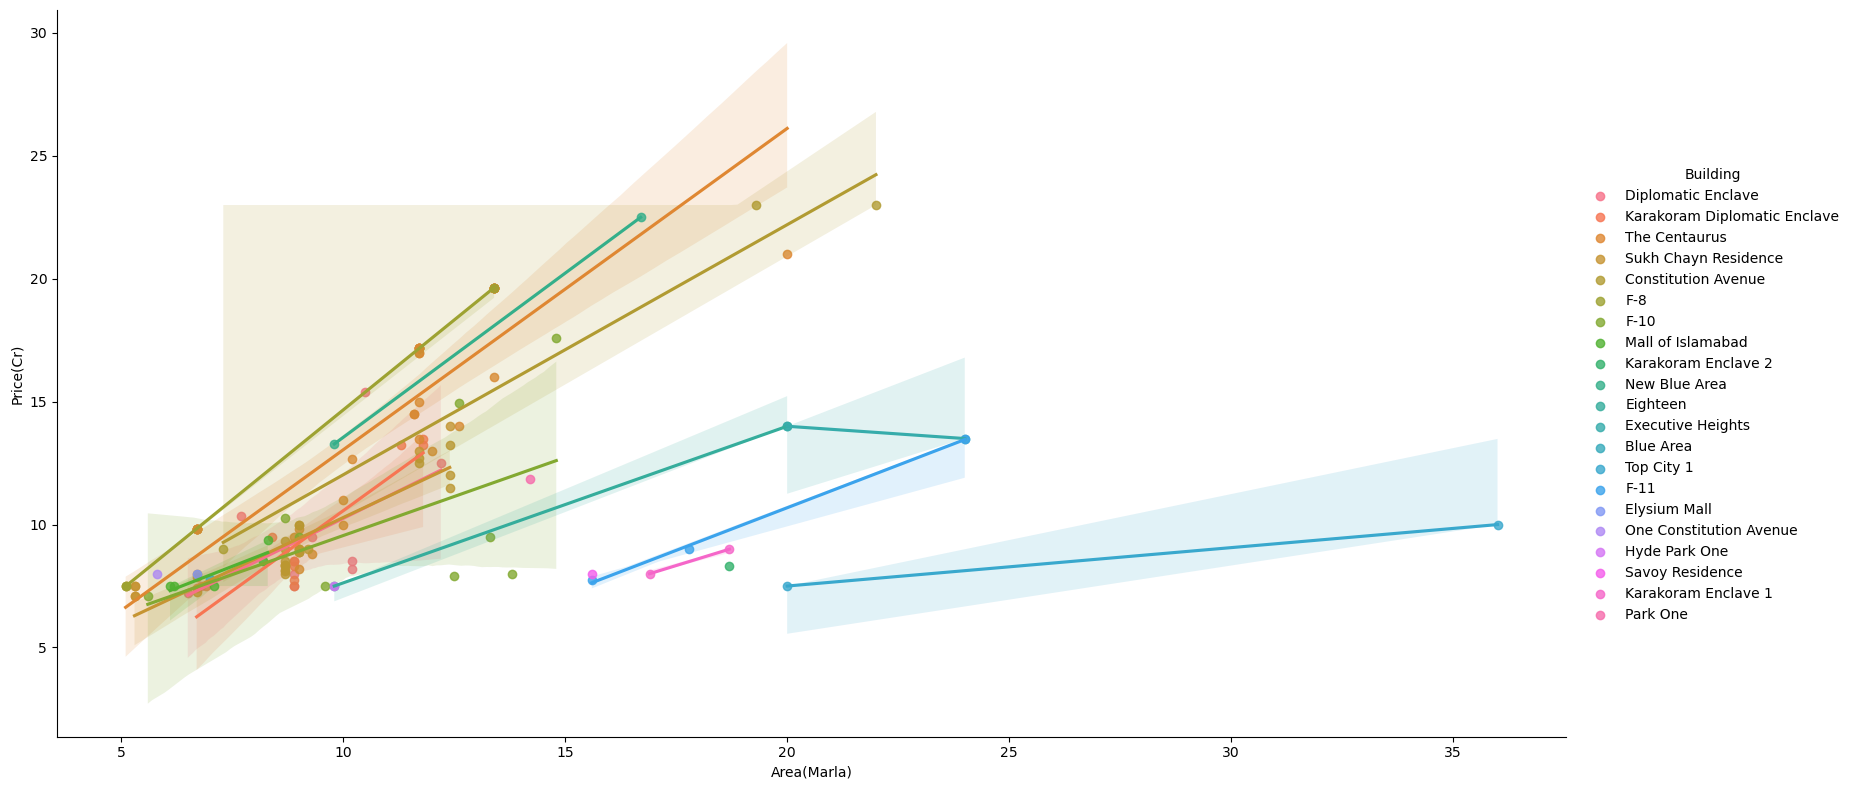

In [18]:
sns.lmplot(data=flats[flats['Price(Cr)']>7],y='Price(Cr)',x='Area(Marla)',hue='Building',height=8, 
    aspect=2)

### Area(Marla)

<Axes: ylabel='Area(Marla)'>

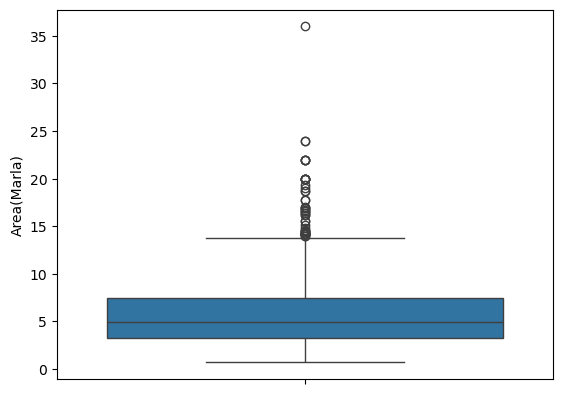

In [19]:
sns.boxplot(flats['Area(Marla)'])

In [20]:
# Investigating Area > 20
flats[flats['Area(Marla)']>20]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
1880,Constitution Avenue,Constitution Avenue,Flat,23.00,4.0,22.0,4.0,Constitution Avenue has many lucrative investm...,"Built in year: 2023, Parking Spaces: 1, Lobby ...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 1...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
2118,Executive Heights,F-11,Penthouse,13.50,4.0,24.0,3.0,Dream home in Islamabad! Welcome to Executive ...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2270,Top City 1,Top City 1,Penthouse,10.00,6.0,36.0,6.0,luxury brand new penthouse top view available ...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3861,Luxus Mall and Residency,Gulberg Greens,Flat,3.80,5.0,22.0,3.0,includes 3200sqft of Covered area 1800sqft of ...,"Built in year: 2022, Parking Spaces, Lobby in ...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 2...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
4449,Luxus Mall and Residency,Gulberg Greens,Penthouse,4.35,NaN,22.0,NaN,"Key Highlights Total Area: 5,000 sq. ft. (3,20...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5068,F-11,F-11,Flat,13.50,3.0,24.0,3.0,This modern Apartment sits on 5500 square feet...,"Built in year: 2022, Parking Spaces: 2, Lobby ...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...",...,NaN,NaN,NaN,NaN,1.0,1.0,NaN,1.0,NaN,NaN
6034,Luxus Mall and Residency,Gulberg Greens,Penthouse,3.85,5.0,22.0,3.0,Gulberg Green Islamabad project name Luxus Mal...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*Removing data where flat's Area > 22*

In [28]:
flats = flats[~(flats['Area(Marla)']>22)]

<Axes: ylabel='Area(Marla)'>

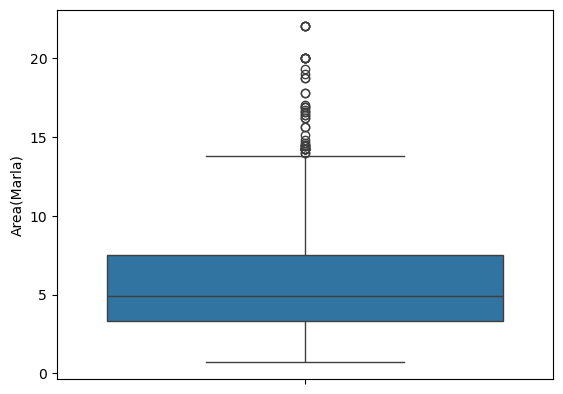

In [29]:
sns.boxplot(flats['Area(Marla)'])

### Bathrooms & Bedrooms

<Axes: xlabel='Bathrooms', ylabel='count'>

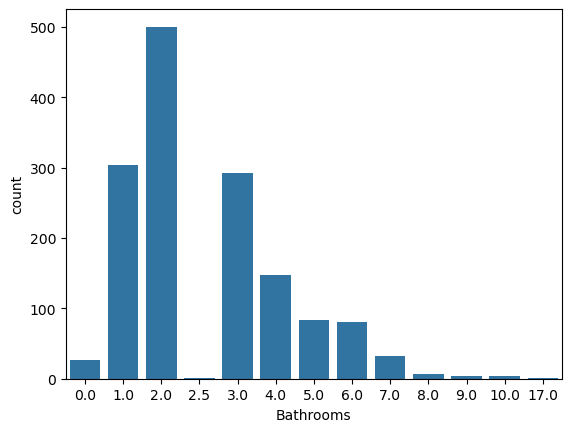

In [33]:
sns.barplot(flats['Bathrooms'].value_counts())

<Axes: xlabel='Bedrooms', ylabel='count'>

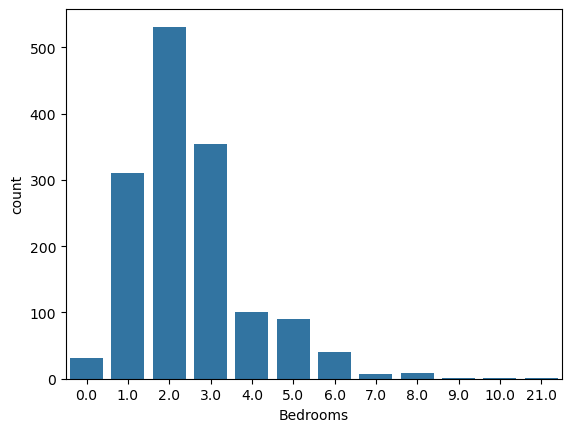

In [36]:
sns.barplot(flats['Bedrooms'].value_counts())

In [37]:
flats[flats['Bathrooms']>5][['Bathrooms','Bedrooms','Price(Cr)','Area(Marla)']]

,Bathrooms,Bedrooms,Price(Cr),Area(Marla)
117,9.0,7.0,0.78,2.4
164,6.0,5.0,0.38,1.6
199,7.0,4.0,23.00,19.3
330,6.0,5.0,1.15,4.9
343,6.0,6.0,1.65,3.3
...,...,...,...,...
6268,7.0,6.0,0.65,2.4
6393,7.0,6.0,1.05,7.6
6458,7.0,7.0,0.75,4.0
6474,6.0,6.0,1.30,4.3


*There are flats where the number of bathrooms and bedrooms are very high that the corresponding Area doesnot make sense*

**Here we have to use Bath(s) and Bedrooms(s) as main features instead of Bathrooms and Bedrooms, because there are alot of errors**

### Bath(s)

In [41]:
flats['Bath(s)'].value_counts()

Bath(s)
2.0    709
1.0    463
3.0    359
4.0    127
5.0     45
6.0      8
7.0      2
9.0      1
Name: count, dtype: int64

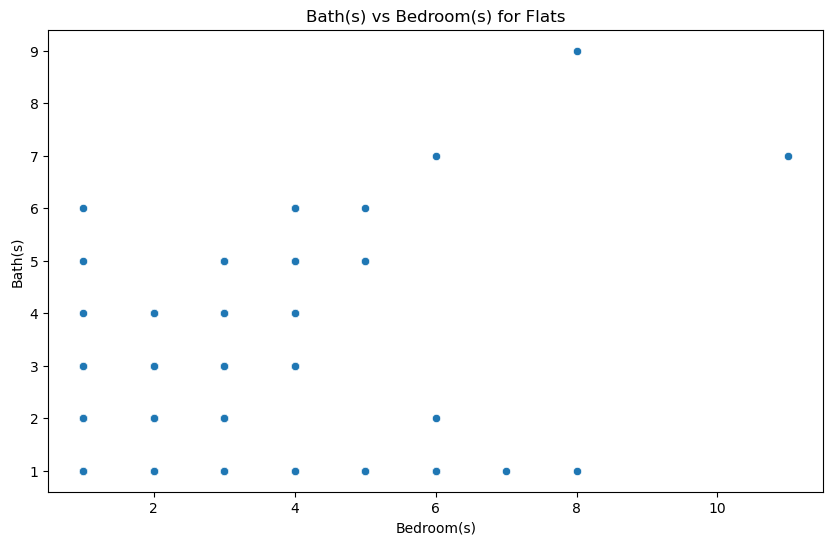

In [42]:
# Check relationship between Bath(s) and Bedroom(s)
plt.figure(figsize=(10,6))
sns.scatterplot(data=flats, x='Bedroom(s)', y='Bath(s)')
plt.title('Bath(s) vs Bedroom(s) for Flats')
plt.show()

In [43]:
# Calculating Difference between Bedrooms(s) and Bath(s)
flats['BedBath_Diff'] = flats['Bedroom(s)'] - flats['Bath(s)']

In [50]:
# Find outliers where difference is > 3 or < -3 (unusual bed/bath ratios)
outlier_rows = flats[(flats['BedBath_Diff']>3) | (flats['BedBath_Diff']<-3)]
print(f"Found {len(outlier_rows)} outliers with unusual Bed/Bath ratio")
outlier_rows[['Price(Cr)', 'Bath(s)', 'Bedroom(s)', 'BedBath_Diff','Area(Marla)', 'Building']]

Found 17 outliers with unusual Bed/Bath ratio


,Price(Cr),Bath(s),Bedroom(s),BedBath_Diff,Area(Marla),Building
117,0.7800,1.0,7.0,6.0,2.4,Cube Apartments
343,1.6500,1.0,6.0,5.0,3.3,F-11
1187,0.5000,1.0,6.0,5.0,2.9,DHA Phase 1
1395,1.0200,1.0,6.0,5.0,1.8,Islamabad Expressway
2150,0.4700,1.0,5.0,4.0,1.4,Gulberg Greens
3044,1.2000,7.0,11.0,4.0,1.6,DHA Phase 2
4311,0.4590,1.0,8.0,7.0,1.2,Mumtaz City
4528,1.4400,1.0,5.0,4.0,1.4,DHA Phase 2
4676,0.4590,1.0,5.0,4.0,1.2,Top City 1
4677,0.4590,1.0,5.0,4.0,1.2,Gandhara City


*For flats, typically bathrooms should be close to bedrooms. Large differnces indicate data errors.*

In [51]:
flats['Description'].loc[117]

'cube Appartments Bahria Enclave Studio Apartment for sale All dues clear inside parking paid 15 lakh. 7th floor Rented 35k'

In [52]:
# Check a few descriptions to understand the data
for idx in outlier_rows.index[:3]:
    print(f"Index {idx}:")
    print(flats['Description'].loc[idx][:200] + "...")
    print("-"*50)

Index 117:
cube Appartments Bahria Enclave Studio Apartment for sale All dues clear inside parking paid 15 lakh. 7th floor Rented 35k...
--------------------------------------------------
Index 343:
Al Rehman associate Offers a Prime Location Luxury 1 Bed Apartment Here are the features: . Luxury Bedrooms . Modern Bathrooms . Drawing dinning . TV Lounge . Kitchen . Big lawn . Servant Quarter . St...
--------------------------------------------------
Index 1187:
Studio Apartment For Sale on Installments. In DHA Phase 1 Islamabad. Project of Zameen. Apartment Size 650 Sq Ft. 1 Studio. 1 Baths. Open Kitchen. Parking Space. Zameen Project. Grand Orchard . Swimmi...
--------------------------------------------------


In [53]:
# Remove outliers with unusual Bed/Bath ratio
print(f"Before removal: {flats.shape[0]} rows")
flats = flats[~((flats['BedBath_Diff']>3) | (flats['BedBath_Diff']<-3))]
print(f"After removal: {flats.shape[0]} rows")

Before removal: 1735 rows
After removal: 1718 rows


In [54]:
# Dropping Bathrooms, Bedrooms
flats.drop(columns=['Bathrooms','Bedrooms'],inplace=True)

## Built in Year Analysis

In [58]:
flats['Built in year'].value_counts().sort_index()

Built in year
0.0         1
1.0        90
2.0         9
3.0         5
4.0         2
5.0         6
7.0         1
8.0         2
10.0        3
12.0        1
15.0        1
21.0        1
23.0        1
28.0        1
1990.0      1
1995.0      1
1999.0      1
2000.0      3
2002.0      2
2004.0      3
2005.0      4
2008.0      3
2009.0      3
2010.0     17
2011.0     10
2012.0     12
2013.0      9
2014.0      7
2015.0     38
2016.0     13
2017.0     22
2018.0     80
2019.0     21
2020.0     96
2021.0     51
2022.0    101
2023.0    152
2024.0    219
2025.0    314
2026.0     43
2027.0     31
2028.0      8
2029.0      1
2030.0      5
2035.0      1
2054.0      1
Name: count, dtype: int64

In [59]:
# Check for year errors (unusual values)
flats[flats['Built in year'] < 1900]['Built in year'].value_counts()

Built in year
1.0     90
2.0      9
5.0      6
3.0      5
10.0     3
8.0      2
4.0      2
7.0      1
21.0     1
28.0     1
15.0     1
23.0     1
12.0     1
0.0      1
Name: count, dtype: int64

In [57]:
# Set brand new flats to 2025
newFlats = flats[(flats['Built in year'] < 1800) & (flats['Description'].str.lower().str.contains('brand new'))].index
flats.loc[newFlats, 'Built in year'] = 2025
print(f"Updated {len(newFlats)} brand new flats to year 2025")

Updated 9 brand new flats to year 2025


In [60]:
# Set remaining invalid years (< 1900) to NaN
nan_years = flats[flats['Built in year'] < 1800].index
flats.loc[nan_years, 'Built in year'] = np.nan
print(f"Set {len(nan_years)} invalid years to NaN")

Set 124 invalid years to NaN


In [62]:
flats['Built in year'].value_counts().sort_index()

Built in year
1990.0      1
1995.0      1
1999.0      1
2000.0      3
2002.0      2
2004.0      3
2005.0      4
2008.0      3
2009.0      3
2010.0     17
2011.0     10
2012.0     12
2013.0      9
2014.0      7
2015.0     38
2016.0     13
2017.0     22
2018.0     80
2019.0     21
2020.0     96
2021.0     51
2022.0    101
2023.0    152
2024.0    219
2025.0    314
2026.0     43
2027.0     31
2028.0      8
2029.0      1
2030.0      5
2035.0      1
2054.0      1
Name: count, dtype: int64

## Floor & Floor in Building Analysis

In [69]:
flats['Floor in Building'].value_counts().sort_index()

Floor in Building
1.0       141
2.0        20
3.0        34
4.0        61
5.0        99
6.0        98
7.0       101
8.0        99
9.0       118
10.0       80
11.0       31
12.0       62
13.0       12
14.0       24
15.0       25
16.0       13
17.0        7
18.0        9
19.0        5
20.0       14
21.0       13
22.0       16
23.0        4
24.0        3
25.0        5
27.0        1
28.0        1
29.0        1
30.0        1
31.0        2
32.0        5
34.0        3
35.0        2
37.0        1
40.0       12
41.0        3
42.0        2
2016.0      1
2025.0      1
Name: count, dtype: int64

In [68]:
flats.loc[flats['Floor in Building'] > 2000,'Built in year' ] = flats['Floor in Building']

*40+ Floors in Building doesn't not make sense, so setting them to Nan*

In [71]:
flats.loc[flats['Floor in Building']>40,'Floor in Building'] = np.nan

In [73]:
# Floor
flats['Floor'].value_counts().sort_index()

Floor
1.0      484
2.0       94
3.0      137
4.0      100
5.0       88
6.0       51
7.0       43
8.0       34
9.0       17
10.0      24
11.0      10
12.0       7
13.0       7
14.0       3
15.0       2
16.0       2
17.0       4
18.0       3
19.0       1
20.0       5
21.0       2
22.0       3
24.0       3
26.0       1
32.0       1
37.0       1
123.0      1
Name: count, dtype: int64

In [76]:
# Removing the highest value for Floor (error)
flats = flats[~(flats['Floor'] == flats['Floor'].max())]

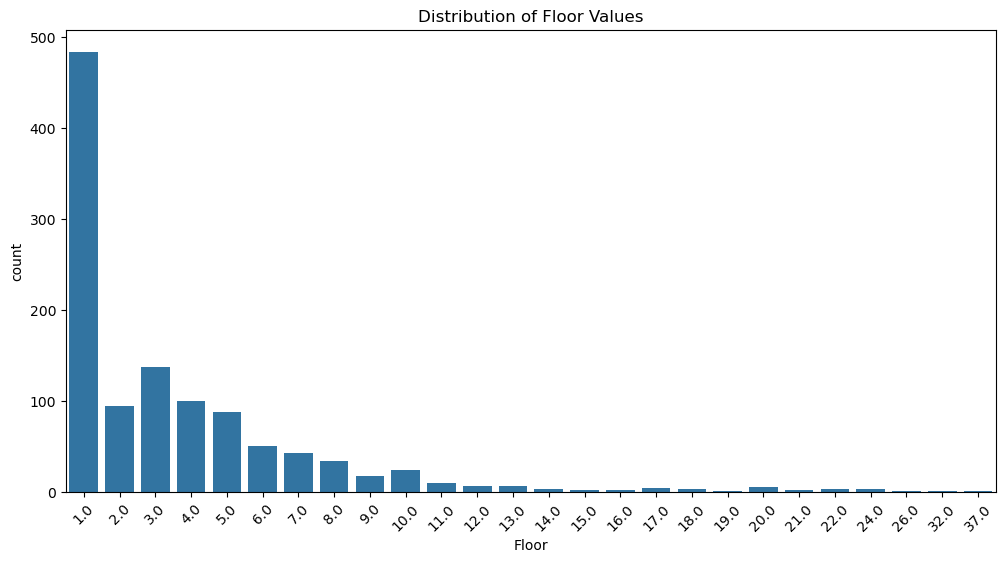

In [77]:
plt.figure(figsize=(12,6))
sns.barplot(flats['Floor'].value_counts().sort_index())
plt.title('Distribution of Floor Values')
plt.xticks(rotation=45)
plt.show()

In [79]:
# Check flats with very high floors
flats[flats['Floor'] > 15][['Price(Cr)', 'Area(Marla)', 'Floor', 'Building', 'Bedroom(s)','Floor in Building']]

,Price(Cr),Area(Marla),Floor,Building,Bedroom(s),Floor in Building
33,3.90,3.0,37.0,The Centaurus,1.0,37.0
155,1.25,6.0,26.0,Goldcrest Views,2.0,34.0
156,2.94,7.3,24.0,Goldcrest Views,3.0,40.0
384,1.06,2.8,17.0,Goldcrest Views,NaN,14.0
440,7.50,7.1,18.0,Mall of Islamabad,2.0,22.0
494,3.35,8.0,21.0,Goldcrest Views,2.0,40.0
577,1.08,2.7,17.0,Goldcrest Views,1.0,40.0
969,3.30,8.0,20.0,G-11,2.0,25.0
1144,7.99,13.8,32.0,F-10,2.0,32.0
1240,9.50,8.9,17.0,The Centaurus,2.0,23.0


In [81]:
flats['Amenities: Main Features'].loc[5816]

'Built in year: 2025, Parking Spaces: 4000, Lobby in Building, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floor: 22, Floors in Building: 40, Elevators: 8, Service Elevators in Building, Furnished'

In [82]:
# Caculating the difference between Floor and Floor in Building to check if there is any error
flats['Floor Diff'] = flats['Floor in Building'] - flats['Floor']

In [83]:
flats['Floor Diff'].value_counts().sort_index()

Floor Diff
-15.0      1
-13.0      1
-10.0      2
-9.0       2
-7.0       2
-6.0       2
-4.0       5
-3.0       6
-2.0       4
-1.0       6
 0.0     175
 1.0      60
 2.0     108
 3.0     112
 4.0     104
 5.0      71
 6.0      65
 7.0      72
 8.0      68
 9.0      37
 10.0     29
 11.0     19
 12.0      7
 13.0     13
 14.0      9
 15.0      7
 16.0      5
 17.0      8
 18.0      6
 19.0      9
 20.0      5
 21.0      5
 22.0      2
 23.0      1
 24.0      2
 25.0      1
 26.0      1
 29.0      3
 30.0      2
 31.0      4
 32.0      1
Name: count, dtype: int64

In [84]:
flats[flats['Floor Diff'] < 0][['Floor','Floor in Building']]

,Floor,Floor in Building
384,17.0,14.0
480,6.0,2.0
481,5.0,4.0
853,9.0,6.0
1633,22.0,13.0
1684,22.0,13.0
1719,14.0,4.0
1877,17.0,4.0
1967,6.0,2.0
2027,8.0,1.0


*Swapping the values of Floor and Floor in Building, where the Difference is negative. Because the error could be that the Agent made an error.*

In [85]:
# Swapping the values where the Floor Diff is negative
mask = flats['Floor Diff'] < 0
cols_to_swap = ['Floor','Floor in Building']

flats.loc[mask,cols_to_swap] = flats.loc[mask,cols_to_swap[::-1]].values

In [86]:
flats.drop(columns='Floor Diff',inplace =True)

*After researching, I came to know that there are few buildings where Floor > 15, but there are also some mistakes.<br>
So that is why I am not changing the column for now but I will use discretization on this column to minimize the effect of Outliers*

### Elevators

<Axes: xlabel='Elevators', ylabel='count'>

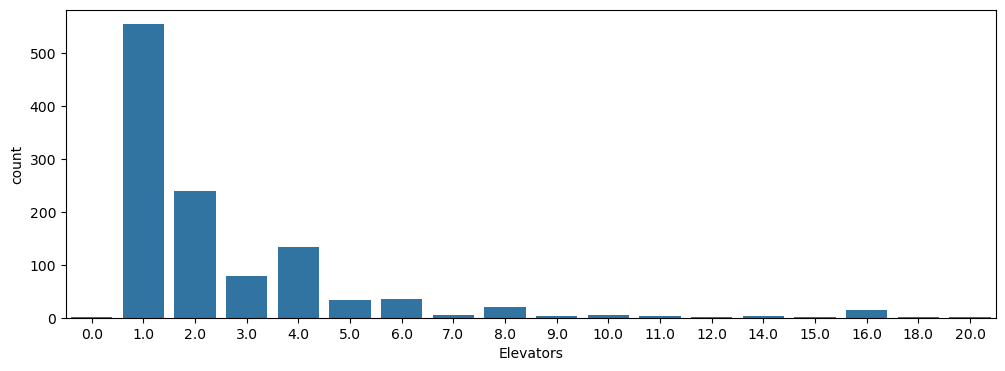

In [87]:
# Value count plot
plt.figure(figsize=(12,4))
sns.barplot(flats['Elevators'].value_counts())

In [92]:
# Capping the value till 10
flats['Elevators'] = flats['Elevators'].clip(lower=0,upper=10)

In [93]:
flats.info()

<class 'pandas.DataFrame'>
Index: 1717 entries, 7 to 6481
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Building                            1717 non-null   str    
 1   Main Location                       1717 non-null   str    
 2   Type                                1717 non-null   str    
 3   Price(Cr)                           1717 non-null   float64
 4   Bath(s)                             1696 non-null   float64
 5   Area(Marla)                         1717 non-null   float64
 6   Bedroom(s)                          1677 non-null   float64
 7   Description                         1717 non-null   str    
 8   Amenities: Main Features            1591 non-null   str    
 9   Amenities: Rooms                    1523 non-null   str    
 10  Amenities: Healthcare Recreational  1249 non-null   str    
 11  Amenities: Other Facilities         1496 non-null   str    

### Kitchens

In [94]:
flats['Kitchens'].value_counts()

Kitchens
 1.0     1079
 0.0      197
 2.0      171
 3.0       15
 11.0       2
 4.0        1
-1.0        1
Name: count, dtype: int64

In [104]:
flats[flats['Kitchens']==0][['Area(Marla)','Bedroom(s)']].head(20)

,Area(Marla),Bedroom(s)
53,3.3,1.0
70,3.6,2.0
103,4.7,2.0
150,7.3,3.0
163,10.0,3.0
297,7.5,3.0
299,7.5,3.0
383,13.3,3.0
418,3.5,1.0
428,3.4,1.0


In [115]:
# Setting to Nan for values where it is either 0 or greater than 3

flats.loc[(flats['Kitchens'] > 3) | (flats['Kitchens']<1),'Kitchens'] = np.nan

### Parking Spaces

<Axes: xlabel='Parking Spaces', ylabel='count'>

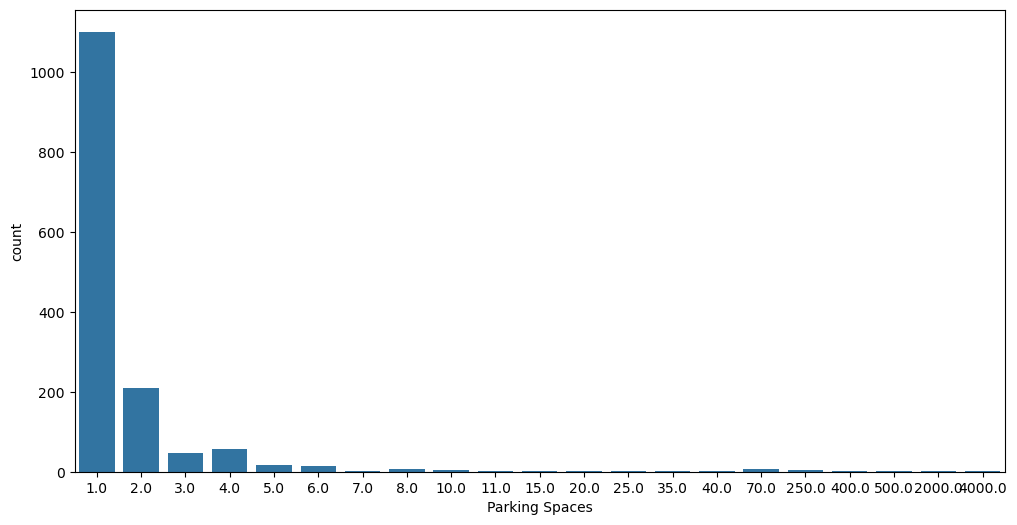

In [117]:
plt.figure(figsize=(12,6))
sns.barplot(flats['Parking Spaces'].value_counts())

In [118]:
# Capping the vaues till 4 for Parking Spaces
flats['Parking Spaces'] =  flats['Parking Spaces'].clip(lower=1,upper=4)

# Multivariate Approach
Now, we will use Multivariate Techiniques to detect Outliers.Following are the techniques:

- Isolation Forest
- Local Outlier Factor

### Isolation Forest

In [124]:
flats.columns

Index(['Building', 'Main Location', 'Type', 'Price(Cr)', 'Bath(s)',
       'Area(Marla)', 'Bedroom(s)', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Floor in Building',
       'Servant Quarters', 'Kitchens', 'Store Rooms', 'Swimming Pool', 'Sauna',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen', 'Storey Unit', 'BedBath_Diff'],
      dtype='str')

In [120]:
# Choosing 'Area','Bedroom(s)','Bath(s)','Kitchens' 
cols_to_use = ['Bath(s)', 'Area(Marla)', 'Bedroom(s)','Kitchens']

data = flats[cols_to_use].copy()

In [121]:
# Filling the missing values

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

data = pd.DataFrame(imputer.fit_transform(data),columns=cols_to_use)
data.head()

,Bath(s),Area(Marla),Bedroom(s),Kitchens
0,2.0,6.5,2.0,1.0
1,4.0,11.8,3.0,1.0
2,3.0,7.3,3.0,1.0
3,2.0,5.0,1.0,1.0
4,1.0,3.9,1.0,1.0


In [126]:
data.isnull().sum()

Bath(s)        0
Area(Marla)    0
Bedroom(s)     0
Kitchens       0
dtype: int64

In [143]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators=400,contamination=0.04)
clf.fit(data)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",400
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.04
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [144]:
y_pred = clf.predict(data)

In [145]:
is_outlier_forest = y_pred == -1

In [149]:
data.loc[is_outlier_forest,cols_to_use].head(60)

,Bath(s),Area(Marla),Bedroom(s),Kitchens
26,5.0,13.3,4.0,2.0
29,2.0,20.0,2.0,1.0
46,6.0,19.3,4.0,2.0
94,6.0,20.0,4.0,1.0
99,1.0,2.1,1.0,3.0
115,5.0,12.0,4.0,2.0
154,5.0,4.2,4.0,1.0
223,4.0,18.7,4.0,1.0
260,4.0,16.7,4.0,1.0
323,4.0,14.8,3.0,2.0


In [132]:
# Local Outlier Factor
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=25,contamination=0.03)

y_pred = lof.fit_predict(data)

C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [133]:
is_outlier_lof = y_pred == -1

In [134]:
data.loc[is_outlier_lof,cols_to_use]

,Bath(s),Area(Marla),Bedroom(s),Kitchens
18,2.0,2.7,2.0,1.0
156,2.0,3.6,3.0,1.0
201,2.0,2.9,2.0,1.0
263,2.0,2.9,2.0,1.0
272,2.0,3.5,2.0,1.0
292,1.0,4.0,2.0,1.0
333,2.0,2.7,2.0,1.0
359,2.0,2.7,1.0,1.0
383,2.0,2.9,2.0,1.0
386,2.0,2.7,2.0,1.0


In [123]:
flats.loc[is_outlier_forest,cols_to_use].index == flats.loc[is_outlier_lof,cols_to_use].index

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])

*After Observing both outliers detected by both, it can be seen that in the outliers detected by Isolation Forest, there were few rows that have Area < 5 but Baths and Bedrooms > 4*

In [153]:
is_outlier_forest_index = flats.loc[is_outlier_forest].loc[(flats['Area(Marla)']<5),cols_to_use].index

In [154]:
is_outlier_forest_index

Index([ 401,  578, 1253, 1465, 1739, 2122, 2284, 3263, 3361, 3845, 3881, 4173,
       4569, 4905, 5132, 5331, 5400, 5480, 5563, 5829, 6384, 6458],
      dtype='int64')

In [155]:
# Removing the Outliers detected by Isolation Forest
flats.drop(index=is_outlier_forest_index,inplace=True)

In [158]:
# Removing the Columns which are not usefull for predicting price
cols_to_remove = ['Type','SolarInstalled','WaterBore', 'CornerHouse', 'Security Staff',
       'Maintenance Staff','Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen', 'Storey Unit']

In [159]:
flats.drop(columns=cols_to_remove,inplace=True)

In [160]:
flats.info()

<class 'pandas.DataFrame'>
Index: 1695 entries, 7 to 6481
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Building                            1695 non-null   str    
 1   Main Location                       1695 non-null   str    
 2   Price(Cr)                           1695 non-null   float64
 3   Bath(s)                             1674 non-null   float64
 4   Area(Marla)                         1695 non-null   float64
 5   Bedroom(s)                          1655 non-null   float64
 6   Description                         1695 non-null   str    
 7   Amenities: Main Features            1570 non-null   str    
 8   Amenities: Rooms                    1502 non-null   str    
 9   Amenities: Healthcare Recreational  1232 non-null   str    
 10  Amenities: Other Facilities         1476 non-null   str    
 11  IsPrimeLoc                          1695 non-null   bool   

In [161]:
flats.to_csv('flats_outlier_handled.csv')